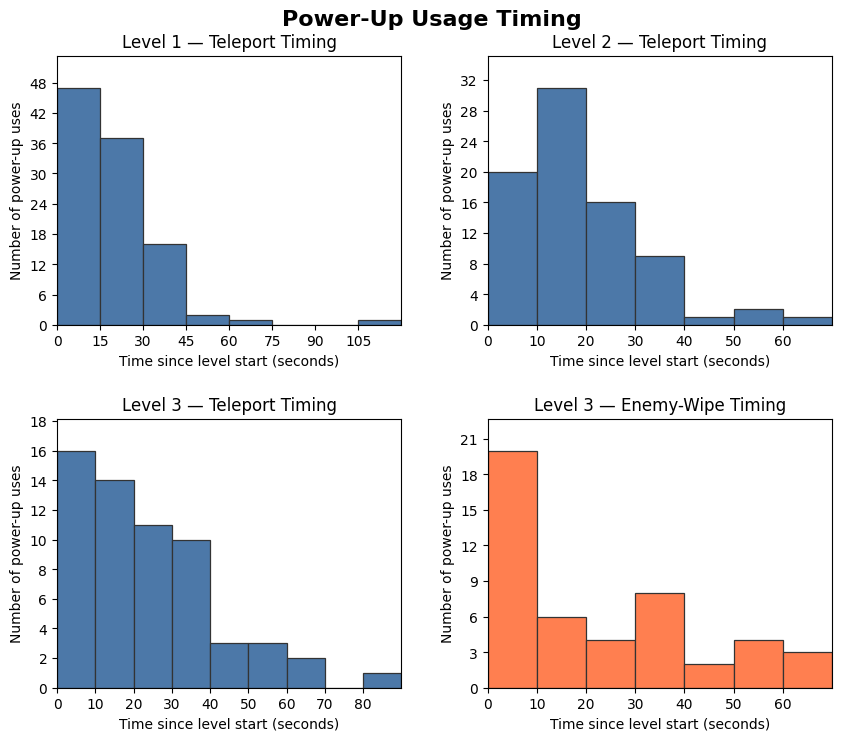

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


CSV_URL   = "https://docs.google.com/spreadsheets/d/1XBXfRUtn90uBryHC0-0a4NKp6yKJxVKYuonOzJrUHLA/export?format=csv&gid=500972784"

COL_LEVEL   = "level"
COL_POWERUP = "powerUpType"
COL_TIME    = "timeSinceLevelStart"
COL_TS      = "ts"

FIXED_BIN_SIZE = None
TARGET_BINS    = 10

COLOR_SWITCH = "#4c78a8"
COLOR_WIPE   = "#ff7f50"

FIG_W, FIG_H = 10, 7.8
HSPACE, WSPACE = 0.35, 0.25
BAR_EDGE = "#333"
BAR_LW   = 0.9

def nice_bin_size(max_value, target_bins=10, min_size=1.0):
    if max_value is None or max_value <= 0 or math.isinf(max_value) or math.isnan(max_value):
        return min_size
    raw = max(max_value / max(target_bins, 1), min_size)
    p10 = 10 ** math.floor(math.log10(raw))
    for m in [1, 2, 5, 10]:
        cand = m * p10
        if cand >= raw:
            return max(cand, min_size)
    return max(10 * p10, min_size)

def series_to_float(arr):
    return pd.to_numeric(pd.Series(arr), errors="coerce").dropna().astype(float).values

def _set_left_edge_ticks(ax, edges, max_labels=16):
    lefts = edges[:-1]
    if len(lefts) == 0:
        return
    if len(lefts) > max_labels:
        stride = int(math.ceil(len(lefts) / max_labels))
        lefts = lefts[::stride]
    labels = [str(int(x)) if float(x).is_integer() else f"{x:g}" for x in lefts]
    ax.set_xticks(lefts)
    ax.set_xticklabels(labels)

def _build_edges(max_time, fixed_bin_size=None, target_bins=10):
    if fixed_bin_size and fixed_bin_size > 0:
        b = float(fixed_bin_size)
    else:
        b = nice_bin_size(max_time, target_bins=target_bins)
    max_edge = max(b, math.ceil(max_time / b) * b)
    edges = np.arange(0, max_edge + b, b)
    return edges, b

def _tighten_axes(ax):
    ax.margins(x=0)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, max(ymax, 1) * 1.08)

def fixed_bin_hist(ax, times, title, color, fixed_bin_size=None, target_bins=10):
    vals = series_to_float(times)
    max_time = float(vals.max()) if vals.size else 0.0
    edges, bin_size = _build_edges(max_time, fixed_bin_size=fixed_bin_size, target_bins=target_bins)

    counts, _ = np.histogram(vals, bins=edges)
    ax.bar(
        edges[:-1], counts,
        width=edges[1]-edges[0], align="edge",
        color=color, edgecolor=BAR_EDGE, linewidth=BAR_LW
    )

    ax.set_title(title)
    ax.set_ylabel("Number of power-up uses")
    ax.set_xlim(0, edges[-1])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(False)

    _set_left_edge_ticks(ax, edges)
    ax.set_xlabel("Time since level start (seconds)")
    _tighten_axes(ax)

if CSV_URL and CSV_URL.startswith("http"):
    df = pd.read_csv(CSV_URL)
elif LOCAL_CSV:
    df = pd.read_csv(LOCAL_CSV)
else:
    raise ValueError("Set CSV_URL or LOCAL_CSV.")

df[COL_TS] = pd.to_datetime(df[COL_TS], errors="coerce", utc=True)

start_date = pd.to_datetime("2025-11-14", utc=True)
end_date   = pd.to_datetime("2025-11-21 23:59:59", utc=True)

df = df[(df[COL_TS] >= start_date) & (df[COL_TS] <= end_date)].copy()


df[COL_LEVEL]   = df[COL_LEVEL].astype(str)
df[COL_POWERUP] = df[COL_POWERUP].astype(str)
df[COL_TIME]    = pd.to_numeric(df[COL_TIME], errors="coerce")
df = df.dropna(subset=[COL_TIME])

def sel(level, powerup):
    return df[(df[COL_LEVEL] == level) & (df[COL_POWERUP] == powerup)][COL_TIME]

fig, axes = plt.subplots(2, 2, figsize=(FIG_W, FIG_H), constrained_layout=False)
(ax11, ax12), (ax21, ax22) = axes

fig.suptitle("Power-Up Usage Timing", y=0.98, fontsize=16, fontweight="bold")
plt.subplots_adjust(top=0.92, hspace=HSPACE, wspace=WSPACE)

fixed_bin_hist(ax11, sel("Level1", "PositionSwitch"),
               "Level 1 — Teleport Timing", COLOR_SWITCH,
               fixed_bin_size=15, target_bins=TARGET_BINS)

fixed_bin_hist(ax12, sel("Level2", "PositionSwitch"),
               "Level 2 — Teleport Timing", COLOR_SWITCH,
               fixed_bin_size=FIXED_BIN_SIZE, target_bins=TARGET_BINS)

fixed_bin_hist(ax21, sel("Level3", "PositionSwitch"),
               "Level 3 — Teleport Timing", COLOR_SWITCH,
               fixed_bin_size=FIXED_BIN_SIZE, target_bins=TARGET_BINS)

fixed_bin_hist(ax22, sel("Level3", "EnemyWipe"),
               "Level 3 — Enemy-Wipe Timing", COLOR_WIPE,
               fixed_bin_size=FIXED_BIN_SIZE, target_bins=TARGET_BINS)

plt.show()

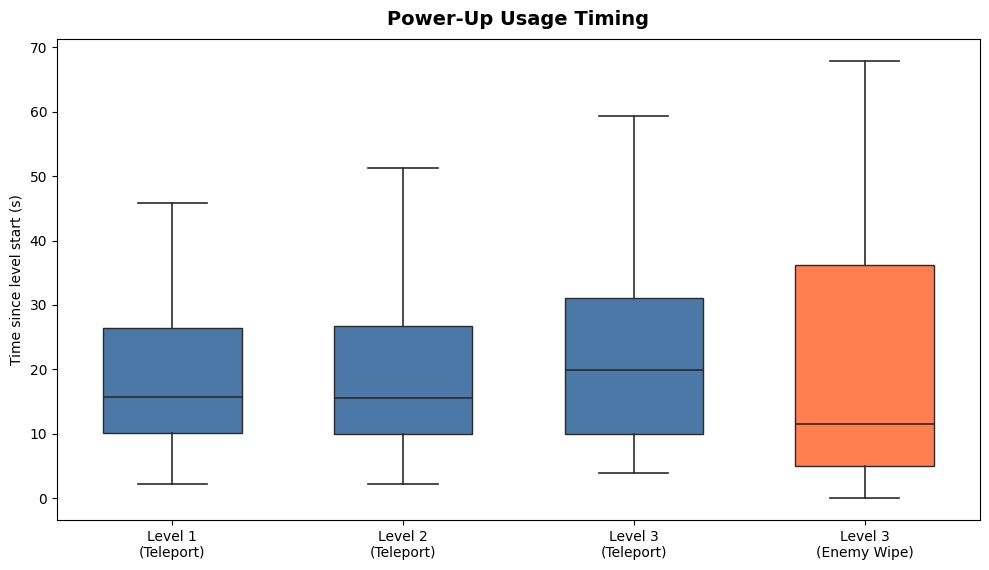

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_URL   = "https://docs.google.com/spreadsheets/d/1XBXfRUtn90uBryHC0-0a4NKp6yKJxVKYuonOzJrUHLA/export?format=csv&gid=500972784"
LOCAL_CSV = None

COL_LEVEL   = "level"
COL_POWERUP = "powerUpType"
COL_TIME    = "timeSinceLevelStart"
COL_TS      = "ts"

COLOR_SWITCH = "#4c78a8"
COLOR_WIPE   = "#ff7f50"
EDGE_COLOR   = "#2b2b2b"

if CSV_URL and CSV_URL.startswith("http"):
    df = pd.read_csv(CSV_URL)
elif LOCAL_CSV:
    df = pd.read_csv(LOCAL_CSV)
else:
    raise ValueError("Set CSV_URL or LOCAL_CSV.")

df[COL_TS] = pd.to_datetime(df[COL_TS], errors="coerce", utc=True)

start_date = pd.to_datetime("2025-11-14", utc=True)
end_date   = pd.to_datetime("2025-11-21 23:59:59", utc=True)

df = df[(df[COL_TS] >= start_date) & (df[COL_TS] <= end_date)].copy()


df[COL_LEVEL]   = df[COL_LEVEL].astype(str)
df[COL_POWERUP] = df[COL_POWERUP].astype(str)
df[COL_TIME]    = pd.to_numeric(df[COL_TIME], errors="coerce")
df = df.dropna(subset=[COL_TIME])


def s(level, powerup):
    return pd.to_numeric(
        df[(df[COL_LEVEL] == level) & (df[COL_POWERUP] == powerup)][COL_TIME],
        errors="coerce"
    ).dropna().values


l1_tp = s("Level1", "PositionSwitch")
l2_tp = s("Level2", "PositionSwitch")
l3_tp = s("Level3", "PositionSwitch")
l3_ew = s("Level3", "EnemyWipe")

data = [l1_tp, l2_tp, l3_tp, l3_ew]
labels = [
    "Level 1\n(Teleport)",
    "Level 2\n(Teleport)",
    "Level 3\n(Teleport)",
    "Level 3\n(Enemy Wipe)"
]

fig, ax = plt.subplots(figsize=(10, 5.8))

bp = ax.boxplot(
    data,
    patch_artist=True,
    showfliers=False,
    widths=0.6
)

fill_colors = [COLOR_SWITCH, COLOR_SWITCH, COLOR_SWITCH, COLOR_WIPE]
for box, fc in zip(bp['boxes'], fill_colors):
    box.set(facecolor=fc, edgecolor=EDGE_COLOR, linewidth=1)

for element in ['whiskers', 'caps', 'medians']:
    for line in bp[element]:
        line.set(color=EDGE_COLOR, linewidth=1.2)

ax.set_xticklabels(labels)
ax.set_ylabel("Time since level start (s)")
ax.set_title("Power-Up Usage Timing", pad=10, fontsize=14, fontweight="bold")
ax.grid(False)
ax.margins(x=0.03)

plt.tight_layout()
plt.show()